In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import torch
from src.data_processing.utils import set_seed
import pandas as pd

from src.models.TimeGAN_torch.timegan_pytorch import TimeGAN
from src.models.TimeGAN_torch.metrics.discriminative_metrics import discriminative_score_metrics
from src.models.TimeGAN_torch.metrics.predictive_metrics import predictive_score_metrics
from src.models.TimeGAN_torch.metrics.visualization_metrics import visualization

from src.data_processing.utils import TimeSeriesDataset

%load_ext autoreload
%autoreload 2

In [2]:
set_seed(42)

Random seed set to: 42


In [3]:
## Newtork parameters
parameters = dict()

parameters['module'] = 'gru'
parameters['hidden_dim'] = 32
parameters['num_layers'] = 3
parameters['batch_size'] = 128
parameters['seq_len'] = 24
parameters['lr'] = 2e-4
parameters['device'] = torch.device("cuda" if torch.cuda.is_available() else "cpu")
parameters['epochs'] = 250
parameters['dataset_name'] = 'VIX'

In [4]:
dataset_name = parameters['dataset_name']
data_path = './data/real_data/VIX_History.csv'
scaler_path= f'./model_checkpoints/scalers/scaler_{dataset_name}.pkl'

# Load and preprocess the data
all_data = pd.read_csv(data_path)
#all_data.drop(['Date'], axis=1, inplace=True)
all_data.drop(['DATE'], axis=1, inplace=True)


parameters['n_seq'] = all_data.shape[1]

# Create dataset object
dataset = TimeSeriesDataset(data=all_data, seq_len=parameters['seq_len'], n_seq=parameters['n_seq'], scaler_path=scaler_path)

# Get train, val, test datasets
train_dataset, val_dataset, test_dataset = dataset.get_datasets()

Initializing TimeSeriesDataset...
Data split: 7092 train, 886 validation, 887 test
Scaler saved at ./model_checkpoints/scalers/scaler_VIX.pkl


## Run TimeGAN for synthetic time-series data generation

TimeGAN uses the original data and network parameters to return the generated synthetic data.

In [5]:
# Run TimeGAN
model = TimeGAN(parameters)

Model initialized with ID: VIX_20250226_221243_d429ed47_n_layers3_seq_len24_n_seq4


In [6]:
model.train(train_dataset, 
            val_dataset, 
            ae_iters=parameters['epochs'], 
            sup_iters=parameters['epochs'], 
            joint_iters=parameters['epochs'], 
            patience = 20)

[Training] Phase 1: Autoencoder
[Autoencoder] Epoch 0/250, Train Loss: 3.0842, Val Loss: 2.0902
[Autoencoder] Epoch 10/250, Train Loss: 1.0825, Val Loss: 1.2927
[Autoencoder] Epoch 20/250, Train Loss: 1.0727, Val Loss: 1.2784
[Autoencoder] Epoch 30/250, Train Loss: 0.8265, Val Loss: 0.9526
[Autoencoder] Epoch 40/250, Train Loss: 0.3132, Val Loss: 0.3696
[Autoencoder] Epoch 50/250, Train Loss: 0.2356, Val Loss: 0.2846
[Autoencoder] Epoch 60/250, Train Loss: 0.2040, Val Loss: 0.2424
[Autoencoder] Epoch 70/250, Train Loss: 0.1833, Val Loss: 0.2080
[Autoencoder] Epoch 80/250, Train Loss: 0.1716, Val Loss: 0.1975
[Autoencoder] Epoch 90/250, Train Loss: 0.1650, Val Loss: 0.1809
[Autoencoder] Epoch 100/250, Train Loss: 0.1585, Val Loss: 0.1753
[Autoencoder] Epoch 110/250, Train Loss: 0.1541, Val Loss: 0.1695
[Autoencoder] Epoch 120/250, Train Loss: 0.1487, Val Loss: 0.1667
[Autoencoder] Epoch 130/250, Train Loss: 0.1456, Val Loss: 0.1597
[Autoencoder] Epoch 140/250, Train Loss: 0.1433, Val Lo

In [8]:
model.load_model('./model_checkpoints/VIX/VIX_20250226_221243_d429ed47_n_layers3_seq_len24_n_seq4')

num_synthetic_samples = len(test_dataset)
synthetic_data = model.generate(num_samples=num_synthetic_samples)
print("synthetic_data shape:", synthetic_data.shape)
# => [100, seq_len, n_seq]

[Model Loaded] Successfully loaded model from ./model_checkpoints/VIX/VIX_20250226_221243_d429ed47_n_layers3_seq_len24_n_seq4 (ID: VIX_20250226_221243_d429ed47_n_layers3_seq_len24_n_seq4)


synthetic_data shape: (863, 24, 4)


## Evaluate the generated data

### 1. Discriminative score

To evaluate the classification accuracy between original and synthetic data using post-hoc RNN network. The output is |classification accuracy - 0.5|.

- metric_iteration: the number of iterations for metric computation.

In [9]:
metric_iteration = 5

discriminative_score = list()
for _ in range(metric_iteration):
  temp_disc = discriminative_score_metrics(test_dataset, synthetic_data, iterations=250)
  discriminative_score.append(temp_disc)

print('Discriminative score: ' + str(np.round(np.mean(discriminative_score), 4)))

Discriminative score: 0.3936


## Evaluate the generated data

### 2. Predictive score

To evaluate the prediction performance on train on synthetic, test on real setting. More specifically, we use Post-hoc RNN architecture to predict one-step ahead and report the performance in terms of MAE.

In [10]:
predictive_score = list()
for tt in range(metric_iteration):
  temp_pred = predictive_score_metrics(test_dataset, synthetic_data, iterations=250)
  predictive_score.append(temp_pred)

print('Predictive score: ' + str(np.round(np.mean(predictive_score), 4)))

Predictive score: 0.028


## Evaluate the generated data

### 3. Visualization

We visualize the original and synthetic data distributions using PCA and tSNE analysis.

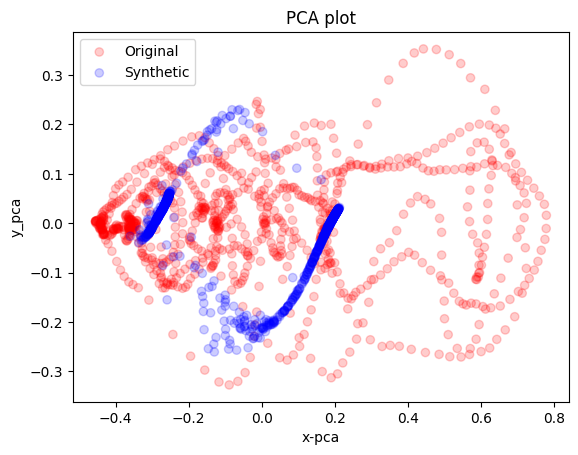

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 1726 samples in 0.001s...
[t-SNE] Computed neighbors for 1726 samples in 0.179s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1726
[t-SNE] Computed conditional probabilities for sample 1726 / 1726
[t-SNE] Mean sigma: 0.010169
[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.067299
[t-SNE] KL divergence after 300 iterations: 0.943369


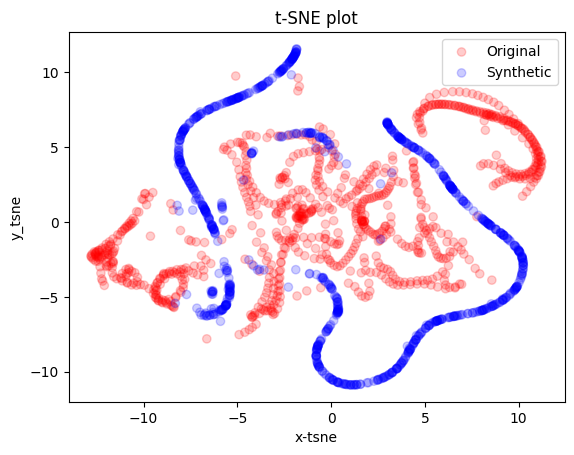

In [11]:
visualization(test_dataset, synthetic_data, 'pca')
visualization(test_dataset, synthetic_data, 'tsne')